# Knowledge Distillation: Teaching a Small Model with a Larger Model

In this notebook, we will:

1. Train a larger **teacher** model.
2. Train a small **student** using only correct labels.
3. Train the same small student using the teacher's predictions.
4. Compare their accuracy and model sizes.

The teacher's predictions contain information beyond the correct class. For example, an image labelled **3** may also look somewhat like an **8**. Distillation lets the student learn from that information.

In [ ]:
# Run this cell only if the imports in the next cell fail.
# %pip install torch scikit-learn matplotlib pandas

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# task

## Our classification task

Each input is an 8 × 8 grayscale image of a handwritten digit. The model must classify it as a digit from **0 to 9**.

We will split the dataset into:

- **Training data:** Used to fit the teacher and students.
- **Validation data:** Used to observe performance during training.
- **Test data:** Used only for the final comparison.

In [3]:
digits = load_digits()

X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full,
)

# Fit preprocessing on training data only.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("Training examples:", len(X_train))
print("Validation examples:", len(X_val))
print("Test examples:", len(X_test))
print("Input features:", X_train.shape[1])
print("Classes:", np.unique(y_train))

Training examples: 1149
Validation examples: 288
Test examples: 360
Input features: 64
Classes: [0 1 2 3 4 5 6 7 8 9]


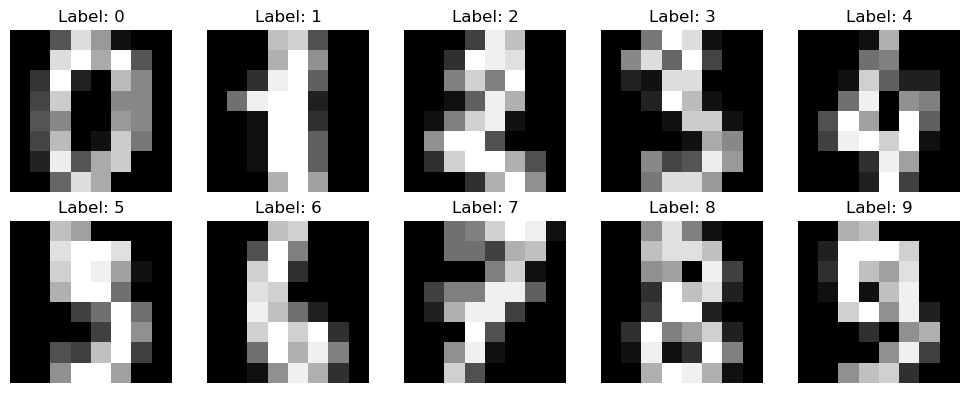

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(
    axes.flat,
    digits.images[:10],
    digits.target[:10],
):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Create data loaders
def make_loader(X, y, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test, y_test)



## Teacher and student

The **teacher** has more hidden units and layers, giving it greater capacity.

The **student** is much smaller. Our goal is to make this small model perform well enough for a setting where model size or inference cost matters.

Both models output **logits**: raw scores for the ten classes. We convert logits to probabilities using softmax.

In [6]:
# Create the model

class Teacher(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.network(x)


class Student(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.network(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


print("Teacher parameters:", count_parameters(Teacher()))
print("Student parameters:", count_parameters(Student()))

Teacher parameters: 50826
Student parameters: 2410


In [7]:

# Training and evaluation helpers
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            predictions = model(inputs).argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total


def train_with_labels(model, loader, epochs=35, learning_rate=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(inputs)
            loss = F.cross_entropy(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)

        history.append(total_loss / len(loader.dataset))

    return history

Teacher validation accuracy: 97.57%


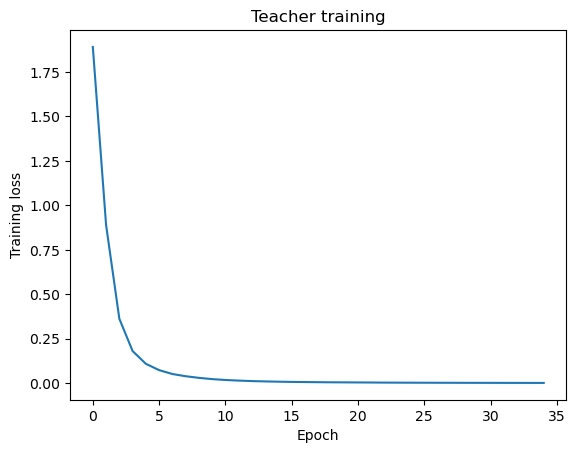

In [8]:
# Train hte teacher

torch.manual_seed(SEED)

teacher = Teacher()
teacher_history = train_with_labels(teacher, train_loader)

print(f"Teacher validation accuracy: {accuracy(teacher, val_loader):.2%}")

plt.plot(teacher_history)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Teacher training")
plt.show()

In [9]:
# Train a student with labels only

torch.manual_seed(SEED)

student_baseline = Student()
baseline_history = train_with_labels(student_baseline, train_loader)

print(
    "Label-only student validation accuracy:",
    f"{accuracy(student_baseline, val_loader):.2%}",
)

Label-only student validation accuracy: 97.22%


## Hard labels and soft targets

A **hard label** identifies one correct class:

> This image is a **3**.

A teacher instead produces a probability distribution across all classes:

> This image is likely a **3**, but an **8** is somewhat plausible.

We call the teacher's probabilities **soft targets**. They can show the student which mistakes are more plausible than others.

A temperature value, \(T\), controls how soft the probabilities are:

$
p_i(T) = \operatorname{softmax}(z_i/T)
$

where \(z_i\) is a logit. A higher temperature produces a flatter probability distribution.

In [10]:
# See the effect of temperature
sample = torch.tensor(X_val[:1], dtype=torch.float32).to(device)
true_label = y_val[0]

teacher.eval()

with torch.no_grad():
    logits = teacher(sample)

print("True label:", true_label)

temperature_results = pd.DataFrame({
    f"T={T}": F.softmax(logits / T, dim=1)
        .cpu()
        .numpy()
        .ravel()
    for T in [1, 2, 4, 8]
})

temperature_results.index.name = "Digit"
display(temperature_results.round(3))

True label: 8


,T=1,T=2,T=4,T=8
Digit,,,,
0,0.000,0.002,0.021,0.053
1,0.001,0.033,0.093,0.110
2,0.000,0.004,0.034,0.066
3,0.003,0.049,0.114,0.122
4,0.000,0.003,0.029,0.061
5,0.000,0.010,0.050,0.081
6,0.000,0.002,0.024,0.056
7,0.000,0.015,0.063,0.091
8,0.993,0.849,0.476,0.249


# The distillation objective



## How the student learns

The distilled student uses two learning signals:

1. **Correct labels:** The student should predict the actual digit.
2. **Teacher probabilities:** The student should produce a distribution similar to the teacher's.

We combine them as:

$
L =
\alpha L_{\text{labels}}
+
(1-\alpha)T^2 L_{\text{teacher}}
$

Here:

- \(L_{\text{labels}}\) is cross-entropy with the correct label.
- \(L_{\text{teacher}}\) measures the difference between teacher and student probabilities.
- \(T\) is the temperature.
- \(\alpha\) controls the balance between the two signals.

The \(T^2\) factor compensates for the change in gradient scale caused by temperature.

# knowledge is transferred through the teacher’s behavior on examples; training changes the student’s weights.

In [ ]:
The training process is:
1. Give the same input to the teacher and student.
2. Record the teacher’s output.
3. Measure how different the student’s output is.
4. Update the student’s weights to reduce that difference.
5. Repeat across many examples.

In [11]:
# Train the student with distillation

In [12]:
def train_with_distillation(
    student,
    teacher,
    loader,
    epochs=35,
    learning_rate=0.001,
    temperature=4.0,
    alpha=0.5,
):
    student = student.to(device)
    teacher = teacher.to(device)

    teacher.eval()
    optimizer = torch.optim.Adam(student.parameters(), lr=learning_rate)

    history = []

    for epoch in range(epochs):
        student.train()
        total_loss = 0

        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            student_logits = student(inputs)

            with torch.no_grad():
                teacher_logits = teacher(inputs)

            label_loss = F.cross_entropy(student_logits, labels)

            teacher_probabilities = F.softmax(
                teacher_logits / temperature,
                dim=1,
            )

            student_log_probabilities = F.log_softmax(
                student_logits / temperature,
                dim=1,
            )

            distillation_loss = F.kl_div(
                student_log_probabilities,
                teacher_probabilities,
                reduction="batchmean",
            ) * (temperature ** 2)

            loss = (
                alpha * label_loss
                + (1 - alpha) * distillation_loss
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)

        history.append(total_loss / len(loader.dataset))

    return history

In [13]:
# Run distillation

In [14]:
torch.manual_seed(SEED)

student_distilled = Student()

distilled_history = train_with_distillation(
    student=student_distilled,
    teacher=teacher,
    loader=train_loader,
    temperature=4.0,
    alpha=0.5,
)

print(
    "Distilled student validation accuracy:",
    f"{accuracy(student_distilled, val_loader):.2%}",
)

Distilled student validation accuracy: 96.53%


In [15]:
# Final comparison on the test set

In [16]:
models = {
    "Teacher": teacher,
    "Student: labels only": student_baseline,
    "Student: distilled": student_distilled,
}

results = pd.DataFrame([
    {
        "Model": name,
        "Parameters": count_parameters(model),
        "Test accuracy": accuracy(model, test_loader),
    }
    for name, model in models.items()
])

results["Test accuracy"] = results["Test accuracy"].map(
    lambda value: f"{value:.2%}"
)

display(results)

,Model,Parameters,Test accuracy
0,Teacher,50826,97.22%
1,Student: labels only,2410,96.39%
2,Student: distilled,2410,95.00%


# Interpret the result

## What did we learn?

Compare the two student rows:

- They have the **same architecture and parameter count**.
- The label-only student learns from the correct answers.
- The distilled student also learns from the teacher's output distribution.

**Discussion:** Did distillation improve test accuracy in this run? Why might its effect change with the dataset, teacher quality, student size, temperature, or value of \(\alpha\)?

A student is not guaranteed to outperform its label-only counterpart. Distillation is an approach we evaluate, not a guaranteed accuracy improvement.

In [ ]:
NOTE: The label-only student uses cross-entropy loss. The distilled student combines cross-entropy with a loss that encourages its predictions to resemble the teacher’s.

In [ ]:
# Participant Exercise

# Exercise: Change temperature and alpha, then compare validation accuracy.
#
# Try:
# temperature = 1.0, 2.0, 4.0, or 8.0
# alpha = 0.2, 0.5, or 0.8

temperature = 2.0
alpha = 0.5

torch.manual_seed(SEED)

experimental_student = Student()

_ = train_with_distillation(
    student=experimental_student,
    teacher=teacher,
    loader=train_loader,
    temperature=temperature,
    alpha=alpha,
)

print("Temperature:", temperature)
print("Alpha:", alpha)
print(
    "Validation accuracy:",
    f"{accuracy(experimental_student, val_loader):.2%}",
)

## How does this relate to LLMs?

The same broad idea applies to language models:

- A large **teacher LLM** produces outputs or token probabilities.
- A smaller **student LLM** learns to reproduce useful teacher behaviour.
- The aim is often a model that is cheaper and faster to run.

There are several forms of distillation. This notebook demonstrated **logit-based knowledge distillation**, where the student learns from the teacher's probability distribution. In LLM work, students may also learn from teacher-generated answers, reasoning traces, or other training signals. Those are related approaches, but they are not the exact training procedure implemented here.

# Part 2: Distillation from an LLM

Suppose a support team receives thousands of short messages. Each message
must be routed to one of four categories:

- ACCOUNT
- BILLING
- TECHNICAL
- DELIVERY

A capable LLM can classify these messages, but calling it for every message
may be unnecessary for this narrow task.

We will:

1. Ask an LLM teacher to label example messages.
2. Train a much smaller student classifier on those labels.
3. Test the student on messages it has never seen.
4. Compare the teacher and student on this specific task.

This is **response or label distillation**. The teacher supplies training
targets, rather than its full token-probability distribution.

## Where can distillation help?

| Situation | Potential benefit |
|---|---|
| Many repeated requests of the same type | Run a small student for routine cases |
| Limited compute or device memory | Deploy a smaller model |
| Low-latency application | Reduce response time for a narrow task |
| Large-scale document processing | Reduce cost per classified item |
| Limited connectivity | Run a suitable student locally |
| Specialized workflow | Teach a student a well-defined subset of teacher behaviour |

These are potential benefits to **measure**, not guarantees. A student may
lose capability, particularly on unfamiliar or complex inputs.

In [17]:
import json
import time
import urllib.error
import urllib.request

OLLAMA_URL = "http://localhost:11434"

def ollama_request(path, payload=None, timeout=120):
    url = OLLAMA_URL + path

    if payload is None:
        request = urllib.request.Request(url)
    else:
        request = urllib.request.Request(
            url,
            data=json.dumps(payload).encode("utf-8"),
            headers={"Content-Type": "application/json"},
            method="POST",
        )

    with urllib.request.urlopen(request, timeout=timeout) as response:
        return json.load(response)


try:
    available_models = ollama_request("/api/tags")["models"]
    model_names = [model["name"] for model in available_models]

    print("Available Ollama models:")
    for name in model_names:
        print(" -", name)

except (urllib.error.URLError, TimeoutError) as error:
    print("Ollama is not reachable.")
    print("Start Ollama and make sure at least one model is installed.")
    print("Details:", error)

Available Ollama models:
 - qwen2.5:1.5b


In [18]:
# Change this if you want to use another installed model.
TEACHER_MODEL = model_names[0] if model_names else None

if TEACHER_MODEL is None:
    raise RuntimeError(
        "No Ollama model was found. Install a model and rerun Cell 24."
    )

print("Teacher model:", TEACHER_MODEL)

Teacher model: qwen2.5:1.5b


In [ ]:
# Preapre message for teacher

In [19]:
training_messages = [
    # ACCOUNT
    "I cannot sign in to my account",
    "Please reset my password",
    "My login code is not arriving",
    "I need to change my account email",
    "My account has been locked",
    "How do I update my profile?",
    "I forgot my username",
    "I want to close my account",
    "Two factor authentication is failing",
    "I cannot verify my identity",

    # BILLING
    "I was charged twice this month",
    "Please send me my invoice",
    "My payment was declined",
    "I need a refund for the last charge",
    "How do I change my payment method?",
    "The amount on my bill is incorrect",
    "I want to cancel the paid subscription",
    "My discount was not applied",
    "Where can I download my receipt?",
    "Why was my card charged today?",

    # TECHNICAL
    "The app crashes when I open it",
    "The website shows an error message",
    "The dashboard is not loading",
    "The software freezes after an update",
    "I cannot upload a file",
    "The search feature is not working",
    "The application is running very slowly",
    "I found a bug in the mobile app",
    "The page remains blank",
    "My data is not syncing",

    # DELIVERY
    "Where is my package?",
    "My order has not arrived",
    "The tracking link is not updating",
    "I received the wrong item",
    "My parcel was delivered to another address",
    "Can I change the delivery date?",
    "Part of my order is missing",
    "The shipment is delayed",
    "My package arrived damaged",
    "When will my order be shipped?",
]

print("Training messages:", len(training_messages))

Training messages: 40


In [20]:
VALID_LABELS = {"ACCOUNT", "BILLING", "TECHNICAL", "DELIVERY"}

def teacher_classify(message):
    prompt = f"""Classify the following customer-support message.

Choose exactly one category:
ACCOUNT
BILLING
TECHNICAL
DELIVERY

Reply with only the category name. No explanation.

Message: {message}
Category:"""

    result = ollama_request(
        "/api/generate",
        {
            "model": TEACHER_MODEL,
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0},
        },
    )

    raw_answer = result["response"].strip().upper()
    first_line = raw_answer.splitlines()[0].strip(" .:*`")

    if first_line not in VALID_LABELS:
        raise ValueError(
            f"Unexpected teacher answer for {message!r}: {raw_answer!r}"
        )

    return first_line


teacher_labels = []

start = time.perf_counter()

for index, message in enumerate(training_messages, start=1):
    label = teacher_classify(message)
    teacher_labels.append(label)
    print(f"{index:02d}. {label:10s} | {message}")

teacher_labeling_seconds = time.perf_counter() - start

print(
    f"\nTeacher labelled {len(training_messages)} messages "
    f"in {teacher_labeling_seconds:.1f} seconds."
)

01. ACCOUNT    | I cannot sign in to my account
02. ACCOUNT    | Please reset my password
03. ACCOUNT    | My login code is not arriving
04. ACCOUNT    | I need to change my account email
05. ACCOUNT    | My account has been locked
06. TECHNICAL  | How do I update my profile?
07. ACCOUNT    | I forgot my username
08. ACCOUNT    | I want to close my account
09. TECHNICAL  | Two factor authentication is failing
10. ACCOUNT    | I cannot verify my identity
11. ACCOUNT    | I was charged twice this month
12. BILLING    | Please send me my invoice
13. TECHNICAL  | My payment was declined
14. ACCOUNT    | I need a refund for the last charge
15. TECHNICAL  | How do I change my payment method?
16. BILLING    | The amount on my bill is incorrect
17. ACCOUNT    | I want to cancel the paid subscription
18. ACCOUNT    | My discount was not applied
19. ACCOUNT    | Where can I download my receipt?
20. TECHNICAL  | Why was my card charged today?
21. TECHNICAL  | The app crashes when I open it
22. TE

## A critical step: inspect the teacher's labels

The student will learn from the teacher's answers, including the teacher's
mistakes. Check the labels before training.

In a real project, use a larger and more representative dataset. Have people
review an appropriate sample, particularly ambiguous or high-impact cases.

In [ ]:
# Review the labels

In [21]:
import pandas as pd

teacher_data = pd.DataFrame({
    "message": training_messages,
    "teacher_label": teacher_labels,
})

display(teacher_data)
print(teacher_data["teacher_label"].value_counts())

,message,teacher_label
0,I cannot sign in to my account,ACCOUNT
1,Please reset my password,ACCOUNT
2,My login code is not arriving,ACCOUNT
3,I need to change my account email,ACCOUNT
4,My account has been locked,ACCOUNT
5,How do I update my profile?,TECHNICAL
6,I forgot my username,ACCOUNT
7,I want to close my account,ACCOUNT
8,Two factor authentication is failing,TECHNICAL
9,I cannot verify my identity,ACCOUNT


teacher_label
ACCOUNT      15
TECHNICAL    15
DELIVERY      8
BILLING       2
Name: count, dtype: int64


In [ ]:
# Our student model

In [ ]:
## Train a small task-specific student

Here, the student is a **TF-IDF + logistic regression classifier**.

It is not a smaller general-purpose LLM. It is a small model trained to
perform **one task** that the LLM teacher demonstrated.

This is useful for teaching the distillation pipeline:

LLM teacher → training labels → small student → independent evaluation

In [ ]:
#Ttrain the student

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

student_classifier = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000),
)

student_classifier.fit(
    teacher_data["message"],
    teacher_data["teacher_label"],
)

print("Student trained.")

Student trained.


In [ ]:
# Inspect new predictions

In [23]:
new_messages = [
    "I was billed for an order I never placed",
    "The sign-in page keeps rejecting my password",
    "My parcel has been stuck in transit",
    "The mobile application closes immediately",
]

student_predictions = student_classifier.predict(new_messages)
student_probabilities = student_classifier.predict_proba(new_messages)

for message, prediction, probabilities in zip(
    new_messages,
    student_predictions,
    student_probabilities,
):
    confidence = probabilities.max()
    print(f"{prediction:10s} | {confidence:.2f} | {message}")

TECHNICAL  | 0.38 | I was billed for an order I never placed
ACCOUNT    | 0.45 | The sign-in page keeps rejecting my password
ACCOUNT    | 0.42 | My parcel has been stuck in transit
TECHNICAL  | 0.49 | The mobile application closes immediately


In [ ]:
# Independent evalution

In [ ]:
## Do not evaluate on the training messages

We need messages the student has not seen. The answers below are set independently of the teacher's training labels.


In [ ]:
# Compare teacher and student

In [24]:
from sklearn.metrics import accuracy_score, classification_report

test_messages = [
    "I no longer have access to the email on my account",
    "Can you unlock my profile?",
    "The invoice lists an extra fee",
    "My refund has not reached my bank",
    "The app hangs every time I submit a form",
    "The website returns a server error",
    "Tracking says delivered but nothing is here",
    "Can the courier come tomorrow instead?",
]

gold_labels = [
    "ACCOUNT",
    "ACCOUNT",
    "BILLING",
    "BILLING",
    "TECHNICAL",
    "TECHNICAL",
    "DELIVERY",
    "DELIVERY",
]

student_test_predictions = student_classifier.predict(test_messages)

teacher_start = time.perf_counter()
teacher_test_predictions = [
    teacher_classify(message) for message in test_messages
]
teacher_test_seconds = time.perf_counter() - teacher_start

student_start = time.perf_counter()
_ = student_classifier.predict(test_messages)
student_test_seconds = time.perf_counter() - student_start

comparison = pd.DataFrame({
    "message": test_messages,
    "correct_label": gold_labels,
    "teacher": teacher_test_predictions,
    "student": student_test_predictions,
})

display(comparison)

print(
    "Teacher accuracy:",
    accuracy_score(gold_labels, teacher_test_predictions),
)
print(
    "Student accuracy:",
    accuracy_score(gold_labels, student_test_predictions),
)

print("\nStudent classification report:")
print(
    classification_report(
        gold_labels,
        student_test_predictions,
        zero_division=0,
    )
)

print(f"Teacher time for this batch: {teacher_test_seconds:.3f} s")
print(f"Student time for this batch: {student_test_seconds:.3f} s")

,message,correct_label,teacher,student
0,I no longer have access to the email on my acc...,ACCOUNT,ACCOUNT,ACCOUNT
1,Can you unlock my profile?,ACCOUNT,ACCOUNT,TECHNICAL
2,The invoice lists an extra fee,BILLING,BILLING,TECHNICAL
3,My refund has not reached my bank,BILLING,ACCOUNT,ACCOUNT
4,The app hangs every time I submit a form,TECHNICAL,TECHNICAL,TECHNICAL
5,The website returns a server error,TECHNICAL,TECHNICAL,TECHNICAL
6,Tracking says delivered but nothing is here,DELIVERY,DELIVERY,TECHNICAL
7,Can the courier come tomorrow instead?,DELIVERY,DELIVERY,TECHNICAL


Teacher accuracy: 0.875
Student accuracy: 0.375

Student classification report:
              precision    recall  f1-score   support

     ACCOUNT       0.50      0.50      0.50         2
     BILLING       0.00      0.00      0.00         2
    DELIVERY       0.00      0.00      0.00         2
   TECHNICAL       0.33      1.00      0.50         2

    accuracy                           0.38         8
   macro avg       0.21      0.38      0.25         8
weighted avg       0.21      0.38      0.25         8

Teacher time for this batch: 17.982 s
Student time for this batch: 0.001 s


In [ ]:
## What does this experiment show?

The teacher supplies knowledge by assigning labels to training messages.
The student learns a compact decision boundary from those examples.

When interpreting the timing results:

- We measured these particular calls on this machine.
- Ollama timing can include model loading and other overhead.
- A fair deployment benchmark should warm up both systems and use many
  representative requests.
- Accuracy on eight examples is only a demonstration.

A useful student should be evaluated on realistic inputs, rare categories,
ambiguous requests, and changes in how people phrase their messages.

In [ ]:
# Add an uncertainty-based fallback

In [25]:
def classify_with_fallback(message, threshold=0.65):
    probabilities = student_classifier.predict_proba([message])[0]
    student_label = student_classifier.classes_[probabilities.argmax()]
    confidence = probabilities.max()

    if confidence >= threshold:
        return {
            "label": student_label,
            "source": "student",
            "student_confidence": round(float(confidence), 3),
        }

    teacher_label = teacher_classify(message)

    return {
        "label": teacher_label,
        "source": "teacher fallback",
        "student_confidence": round(float(confidence), 3),
    }


examples = [
    "My app is crashing",
    "Where is the refund for my damaged package?",
    "Please change the address and resend my order",
]

for message in examples:
    print(message)
    print(classify_with_fallback(message))
    print()

My app is crashing
{'label': 'TECHNICAL', 'source': 'teacher fallback', 'student_confidence': 0.436}

Where is the refund for my damaged package?
{'label': 'ACCOUNT', 'source': 'teacher fallback', 'student_confidence': 0.363}

Please change the address and resend my order
{'label': 'DELIVERY', 'source': 'teacher fallback', 'student_confidence': 0.348}



In [ ]:
## A practical deployment pattern

1. Let the small student handle messages it can classify reliably.
2. Send uncertain or complex messages to the stronger teacher.
3. Review mistakes and collect more examples.
4. Retrain and evaluate the student.

**Important:** A classifier's reported probability is not automatically a trustworthy confidence score. Choose and validate a fallback threshold using
a separate validation set. Also consider whether certain message types should always go to a human or a more capable system.

## Two ways of transferring knowledge

| Digits experiment | LLM experiment |
|---|---|
| Teacher provides class probabilities | Teacher provides class labels |
| Student is a smaller neural network | Student is a task-specific classifier |
| Uses KL divergence and temperature | Uses teacher-labelled training examples |
| Demonstrates logit-based distillation | Demonstrates response/label distillation |

In both cases, the key idea is:

> Use a capable teacher to create a learning signal for a smaller student.

The student is then evaluated independently on the task we want it to perform.

In [ ]:
# How this extends to a smaller LLM

In [ ]:
## What if the student is also an LLM?

For a smaller LLM, the workflow can be:

1. Collect representative prompts for a specific task.
2. Ask a stronger teacher LLM for high-quality responses.
3. Review and filter those responses.
4. Fine-tune a smaller LLM on prompt–response pairs.
5. Evaluate it on held-out prompts.
6. Compare quality, latency, memory use, and serving cost.

Examples of tasks:

- Summarizing a particular type of report
- Extracting fields from domain documents
- Producing answers in a required format
- Handling common support questions
- Generating a restricted type of code
- Following an organization's writing conventions

If teacher token probabilities are available, training can also use probability-based objectives like the one in Part 1. If only completed
responses are available, prompt–response training is a more accessible route.

**Do not claim that the student has inherited all of the teacher's abilities.** Evaluate the specific behaviour you taught it.